# Entrega — Predicción de resultados del fútbol uruguayo

Se comparan un árbol ID3 y un clasificador Naive Bayes de implementación propia con Random Forest, Naive Bayes categórico de scikit-learn y una regla histórica de referencia.

Los atributos se calculan a partir del historial de partidos. Los hiperparámetros se seleccionan mediante validación temporal de 2005 a 2023. A continuación se ajusta **un único modelo por clasificador con 2019–2023** y se evalúa sobre el período disponible de febrero de 2024 a junio de 2025. Durante ese período se actualizan los atributos con los resultados anteriores a cada partido, mientras que el modelo permanece fijo.

El notebook se ejecuta desde `Tarea1/notebooks/` y utiliza únicamente el CSV `../datos/futbol_uruguayo.csv`, los módulos de `../src/` y las bibliotecas indicadas en `../../requirements.txt`. Todas las métricas, tablas y gráficas se calculan durante la ejecución; no se requieren resultados precalculados ni otros notebooks.


## 1. Carga del dataset y construcción de atributos

Se cargan los partidos y se calculan los atributos históricos causales
(historial reciente, forma, ELO, paridad entre los equipos, etc.) con
`load_dataset`. Estos atributos usan, para cada partido, solamente
información de partidos **anteriores** a esa fecha — no hay fuga de
información hacia el futuro.

In [1]:
import sys
from pathlib import Path

# El notebook se ejecuta desde Tarea1/notebooks; el código está en ../src.
sys.path.insert(0, str(Path("../src").resolve()))

import random
from math import prod

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score, classification_report,
)

from load import load_dataset
from pipeline import create_model_pipeline, pipeline_input_attributes, model_attributes
import reportes as R
from evaluacion import (VALIDATION_YEARS, construir_folds, evaluar_folds,
                        resumen_metricas, ajustar_final, evaluar_ventanas)

dataset = load_dataset("../datos/futbol_uruguayo.csv")
dataset.head()

,home,away,date,gh,ga,result,record_difference,last_matches_difference,goal_difference_value,attack_difference,defense_difference,draw_rate_average,h2h_difference,rest_days_difference,local_experience,away_experience,record_enough,elo_difference,elo_closeness
0,Bella Vista,Defensor Sporting,1932-03-05,1,2,V,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,CA Penarol,River Plate,1932-03-05,1,1,E,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Central Espanol,Rampla Juniors Futbol Club,1932-03-05,1,0,L,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Montevideo Wanderers,Racing Club,1932-03-05,3,0,L,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Nacional,Institucion Atletica Sud America,1932-03-05,2,0,L,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Separación temporal entre desarrollo y test

Los partidos anteriores a 2024 se utilizan para el desarrollo y la validación de los modelos. Los partidos desde 2024 se reservan para la evaluación de la sección 8 y no intervienen en la búsqueda de hiperparámetros ni en el análisis de sensibilidad.


In [2]:
test_start = pd.Timestamp("2024-01-01")

train = dataset[dataset["date"] < test_start].copy()
test = dataset[dataset["date"] >= test_start].copy()

assert not train.empty, "El conjunto de entrenamiento esta vacio"
assert (train["date"] < test_start).all()
assert (test["date"] >= test_start).all()

X_train = train[pipeline_input_attributes].copy()
y_train = train["result"].copy()

print("Partidos de entrenamiento/validacion cruzada:", len(train))
print("Partidos de test reservados (se usan en la seccion 8):", len(test))

Partidos de entrenamiento/validacion cruzada: 14734
Partidos de test reservados (se usan en la seccion 8): 472


## 3. Folds temporales

Se valida cada año de **2005 a 2023 inclusive (19 folds)**, con entrenamiento sobre los cinco años anteriores. De este modo se incluye 2023, el último año completo anterior al test. La ventana de cinco años mantiene un tamaño de entrenamiento comparable al del ajuste final.

El análisis anual orienta la selección de hiperparámetros. La evaluación final corresponde a un período más largo durante el cual el modelo se mantiene fijo, sin reentrenamiento en 2025.


In [3]:
validation_years = list(VALIDATION_YEARS)
window_years = 5
train_years = train["date"].dt.year.to_numpy()
temporal_splits = construir_folds(train, validation_years, window_years)
print(f"Folds temporales: {len(temporal_splits)} (2005-2023)")
for year, (fit_idx, val_idx) in zip(validation_years, temporal_splits):
    print(f"Validacion {year}: entrenamiento={len(fit_idx)}, validacion={len(val_idx)}")


Folds temporales: 19 (2005-2023)
Validacion 2005: entrenamiento=1338, validacion=308
Validacion 2006: entrenamiento=1355, validacion=273
Validacion 2007: entrenamiento=1383, validacion=258
Validacion 2008: entrenamiento=1396, validacion=251
Validacion 2009: entrenamiento=1341, validacion=255
Validacion 2010: entrenamiento=1345, validacion=243
Validacion 2011: entrenamiento=1280, validacion=241
Validacion 2012: entrenamiento=1248, validacion=241
Validacion 2013: entrenamiento=1231, validacion=241
Validacion 2014: entrenamiento=1221, validacion=243
Validacion 2015: entrenamiento=1209, validacion=241
Validacion 2016: entrenamiento=1207, validacion=240
Validacion 2017: entrenamiento=1206, validacion=302
Validacion 2018: entrenamiento=1267, validacion=261
Validacion 2019: entrenamiento=1287, validacion=299
Validacion 2020: entrenamiento=1343, validacion=175
Validacion 2021: entrenamiento=1277, validacion=367
Validacion 2022: entrenamiento=1404, validacion=298
Validacion 2023: entrenamiento=

## 4. Selección de hiperparámetros

Para cada uno de los cuatro clasificadores se busca la mejor
configuración de hiperparámetros con `RandomizedSearchCV`, usando
exclusivamente los folds temporales construidos arriba (nunca el test) y
seleccionando por **F1 macro medio anual** (da igual peso a cada año, en
vez de a cada partido). Se prueban 500 configuraciones por modelo, con
semilla fija (42) para que la búsqueda sea reproducible.

Los cuatro modelos comparten el mismo espacio de búsqueda para los
márgenes de discretización de los atributos —incluyendo los umbrales del
atributo de paridad `match_evenness`— y cada uno agrega, además, sus
propios hiperparámetros específicos.

Como referencia adicional (no como candidato a entregar) se incluye
también el **clasificador base** (`../src/baseClassifier/base_classifier.py`):
una regla simple que compara la tasa histórica de victorias de local y
visitante, sin atributos discretizados ni hiperparámetros elegidos por
validación cruzada. Sirve de piso para saber cuánto aportan realmente los
clasificadores entrenados.

In [4]:
scoring = {"accuracy": "accuracy", "balanced_accuracy": "balanced_accuracy", "f1_macro": "f1_macro"}
selection_metric = "f1_macro"
labels = ["L", "E", "V"]
target_names = ["Local", "Empate", "Visitante"]

# Rangos de discretización compartidos por los cuatro modelos.
grilla_discretizacion = {
    "preprocessing__differences__discretizer__h2h_margin": [0.05, 0.10, 0.15, 0.20, 0.25, 0.30],
    "preprocessing__differences__discretizer__rest_days_margin": [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0],
    "preprocessing__differences__discretizer__record_margin": [0.05, 0.055, 0.06, 0.065, 0.07, 0.075, 0.08, 0.085, 0.1],
    "preprocessing__differences__discretizer__last_matches_margin": [0.0, 0.005, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07],
    "preprocessing__differences__discretizer__goal_difference_margin": [0.15, 0.18, 0.2, 0.22, 0.25, 0.5, 0.7, 0.725, 0.75, 0.8, 0.85, 0.9],
    "preprocessing__differences__discretizer__attack_margin": [0.0, 0.02, 0.05, 0.1, 0.2, 0.22, 0.25, 0.28, 0.3],
    "preprocessing__differences__discretizer__defense_margin": [0.0, 0.01, 0.02, 0.05, 0.1, 0.15, 0.2, 0.22, 0.25, 0.3],
    "preprocessing__differences__discretizer__elo_margin": [25.0, 50.0, 75.0, 100.0, 150.0],
    "preprocessing__draw_rate__discretizer__low_threshold": [0.14, 0.16, 0.2, 0.25, 0.3, 0.32, 0.35],
    "preprocessing__draw_rate__discretizer__high_threshold": [0.35, 0.38, 0.4, 0.45, 0.5, 0.53, 0.55, 0.6],
    "preprocessing__evenness__discretizer__low_threshold": [20.0, 25.0, 30.0, 34.0, 40.0, 50.0, 60.0],
    "preprocessing__evenness__discretizer__high_threshold": [100.0, 120.0, 130.0, 150.0, 175.0, 200.0],
}


def muestrear_candidatos(grilla, n_iter, random_state):
    # Se muestrean configuraciones únicas sin materializar el producto
    # completo de todas las combinaciones posibles.
    rng = random.Random(random_state)
    nombres = sorted(grilla)
    cantidad = min(n_iter, prod(len(v) for v in grilla.values()))
    vistos = set()
    candidatos = []
    while len(candidatos) < cantidad:
        valores = tuple(rng.choice(grilla[nombre]) for nombre in nombres)
        if valores not in vistos:
            vistos.add(valores)
            candidatos.append({nombre: [valor] for nombre, valor in zip(nombres, valores)})
    return candidatos, cantidad


def buscar_hiperparametros(modelo, grilla_extra, nombre, n_iter=500, random_state=42):
    grilla = {**grilla_discretizacion, **grilla_extra}
    pipeline = create_model_pipeline(modelo, include_evenness=True)
    candidatos, cantidad = muestrear_candidatos(grilla, n_iter, random_state)

    busqueda = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=candidatos,
        n_iter=cantidad,
        scoring=scoring,
        refit=False,
        error_score="raise",
        cv=temporal_splits,
        n_jobs=-1,
        random_state=random_state,
        verbose=1,
    )
    busqueda.fit(X_train, y_train)

    mejor_indice = int(np.nanargmax(busqueda.cv_results_["mean_test_f1_macro"]))
    busqueda.selected_index_ = mejor_indice
    busqueda.selected_params_ = busqueda.cv_results_["params"][mejor_indice]
    busqueda.selected_template_ = clone(pipeline).set_params(**busqueda.selected_params_)
    print(f"\n{nombre}")
    print("Mejores hiperparametros:", busqueda.selected_params_)
    print(f"F1 macro medio anual: {busqueda.cv_results_['mean_test_f1_macro'][mejor_indice]:.3%}")
    print(f"Accuracy media anual: {busqueda.cv_results_['mean_test_accuracy'][mejor_indice]:.3%}")
    print(f"Balanced accuracy media anual: {busqueda.cv_results_['mean_test_balanced_accuracy'][mejor_indice]:.3%}")
    return busqueda

### 4.0 Clasificador base (referencia)

Se utiliza una regla que compara las tasas históricas de victorias de los equipos local y visitante. Se establece una ventana fija de diez años (`years_limit=10`), sin optimización por validación cruzada. Esta referencia permite cuantificar el aporte de los clasificadores entrenados frente a una estrategia sencilla.


In [5]:
from baseClassifier.base_classifier import base_classifier

BASE_YEARS_LIMIT = 10

### 4.1 Árbol de decisión ID3 (propio)

In [6]:
from decisionTree.classifier import Classifier as DecisionTreeClassifier

grilla_arbol = {
    "model__min_info_gain": [
        0.0045, 0.005, 0.0055, 0.00575, 0.006, 0.00625, 0.0065,
        0.00675, 0.007, 0.00725, 0.0075, 0.008, 0.0085,
    ],
    # Soporte minimo de cada rama observada.
    "model__min_samples_leaf": [1, 5, 10, 20, 30, 50],

}
busqueda_arbol = buscar_hiperparametros(DecisionTreeClassifier(), grilla_arbol, "Arbol ID3 (propio)")

Fitting 19 folds for each of 500 candidates, totalling 9500 fits

Arbol ID3 (propio)
Mejores hiperparametros: {'preprocessing__evenness__discretizer__low_threshold': 30.0, 'preprocessing__evenness__discretizer__high_threshold': 175.0, 'preprocessing__draw_rate__discretizer__low_threshold': 0.2, 'preprocessing__draw_rate__discretizer__high_threshold': 0.5, 'preprocessing__differences__discretizer__rest_days_margin': 6.0, 'preprocessing__differences__discretizer__record_margin': 0.075, 'preprocessing__differences__discretizer__last_matches_margin': 0.01, 'preprocessing__differences__discretizer__h2h_margin': 0.25, 'preprocessing__differences__discretizer__goal_difference_margin': 0.8, 'preprocessing__differences__discretizer__elo_margin': 75.0, 'preprocessing__differences__discretizer__defense_margin': 0.25, 'preprocessing__differences__discretizer__attack_margin': 0.22, 'model__min_samples_leaf': 1, 'model__min_info_gain': 0.00575}
F1 macro medio anual: 39.610%
Accuracy media anual: 41.

### 4.2 Naive Bayes M-estimador (propio)

In [7]:
from naiveBayes.bayes import M_Estimator as BayesClassifier

grilla_bayes = {
    "model__m": [0.0, 0.5, 1.0, 2.0, 5.0],
    "model__fit_prior": [False, True],
}
busqueda_bayes = buscar_hiperparametros(BayesClassifier(), grilla_bayes, "Bayes M-estimador (propio)")

Fitting 19 folds for each of 500 candidates, totalling 9500 fits

Bayes M-estimador (propio)
Mejores hiperparametros: {'preprocessing__evenness__discretizer__low_threshold': 40.0, 'preprocessing__evenness__discretizer__high_threshold': 120.0, 'preprocessing__draw_rate__discretizer__low_threshold': 0.35, 'preprocessing__draw_rate__discretizer__high_threshold': 0.45, 'preprocessing__differences__discretizer__rest_days_margin': 3.0, 'preprocessing__differences__discretizer__record_margin': 0.085, 'preprocessing__differences__discretizer__last_matches_margin': 0.0, 'preprocessing__differences__discretizer__h2h_margin': 0.05, 'preprocessing__differences__discretizer__goal_difference_margin': 0.85, 'preprocessing__differences__discretizer__elo_margin': 75.0, 'preprocessing__differences__discretizer__defense_margin': 0.02, 'preprocessing__differences__discretizer__attack_margin': 0.22, 'model__m': 2.0, 'model__fit_prior': False}
F1 macro medio anual: 42.053%
Accuracy media anual: 44.186%
Bala

### 4.3 Random Forest (scikit-learn)

Se incluye un ensamble de árboles como referencia frente al ID3 individual. Ambos reciben las mismas variables de entrada, aunque se seleccionan por separado sus márgenes de discretización y sus hiperparámetros. El bosque utiliza árboles binarios de scikit-learn; la comparación no representa exclusivamente el efecto de combinar copias del ID3 propio.


In [8]:
from sklearn.ensemble import RandomForestClassifier

grilla_rf = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 5, 8, 10, 15, 20],
    "model__min_samples_leaf": [1, 2, 5, 10, 20, 40],

    "model__max_features": ["sqrt", "log2", None],
    "model__criterion": ["gini", "entropy"],
    "model__class_weight": [None, "balanced", "balanced_subsample"],
}
busqueda_rf = buscar_hiperparametros(
    RandomForestClassifier(random_state=42, n_jobs=1), grilla_rf, "Random Forest (sklearn)"
)

Fitting 19 folds for each of 500 candidates, totalling 9500 fits

Random Forest (sklearn)
Mejores hiperparametros: {'preprocessing__evenness__discretizer__low_threshold': 20.0, 'preprocessing__evenness__discretizer__high_threshold': 100.0, 'preprocessing__draw_rate__discretizer__low_threshold': 0.14, 'preprocessing__draw_rate__discretizer__high_threshold': 0.55, 'preprocessing__differences__discretizer__rest_days_margin': 7.0, 'preprocessing__differences__discretizer__record_margin': 0.075, 'preprocessing__differences__discretizer__last_matches_margin': 0.05, 'preprocessing__differences__discretizer__h2h_margin': 0.3, 'preprocessing__differences__discretizer__goal_difference_margin': 0.8, 'preprocessing__differences__discretizer__elo_margin': 25.0, 'preprocessing__differences__discretizer__defense_margin': 0.3, 'preprocessing__differences__discretizer__attack_margin': 0.05, 'model__n_estimators': 300, 'model__min_samples_leaf': 40, 'model__max_features': 'sqrt', 'model__max_depth': Non

### 4.4 Naive Bayes categórico (scikit-learn)

In [9]:
from sklearn.naive_bayes import CategoricalNB

# Cardinalidad de cada columna que recibe el modelo, en el orden que arma
# create_preprocessing: differences (x8, 3 categorias c/u) -> draw_rate
# (x1, 3 categorias) -> evenness (x1, 3 categorias) -> numeric
# (local_experience: 4, away_experience: 4, record_enough: 2).
min_categories = [3] * 8 + [3] + [3] + [4, 4, 2]
assert len(min_categories) == len(model_attributes)

grilla_nb = {
    "model__alpha": [0.1, 0.5, 1.0, 2.0, 5.0, 10.0],
    "model__fit_prior": [False, True],
}
busqueda_nb = buscar_hiperparametros(
    CategoricalNB(min_categories=min_categories), grilla_nb, "Naive Bayes categorico (sklearn)"
)

Fitting 19 folds for each of 500 candidates, totalling 9500 fits

Naive Bayes categorico (sklearn)
Mejores hiperparametros: {'preprocessing__evenness__discretizer__low_threshold': 60.0, 'preprocessing__evenness__discretizer__high_threshold': 200.0, 'preprocessing__draw_rate__discretizer__low_threshold': 0.32, 'preprocessing__draw_rate__discretizer__high_threshold': 0.55, 'preprocessing__differences__discretizer__rest_days_margin': 4.0, 'preprocessing__differences__discretizer__record_margin': 0.1, 'preprocessing__differences__discretizer__last_matches_margin': 0.04, 'preprocessing__differences__discretizer__h2h_margin': 0.05, 'preprocessing__differences__discretizer__goal_difference_margin': 0.9, 'preprocessing__differences__discretizer__elo_margin': 75.0, 'preprocessing__differences__discretizer__defense_margin': 0.25, 'preprocessing__differences__discretizer__attack_margin': 0.3, 'model__fit_prior': False, 'model__alpha': 0.5}
F1 macro medio anual: 41.966%
Accuracy media anual: 44.20

## 5. Validación agrupada

La configuración seleccionada se reentrena en cada fold y se agrupan las predicciones de validación. Se informa tanto la media anual utilizada para la selección como las métricas calculadas sobre todas las predicciones agrupadas. Estos resultados corresponden a la validación utilizada durante el desarrollo y no constituyen una evaluación independiente de la selección.


In [10]:
def evaluar_agrupado(busqueda, nombre):
    resumen, y_real, y_pred, metricas_anuales = evaluar_folds(
        busqueda.selected_template_, X_train, y_train, temporal_splits
    )
    print(f"\n{nombre}")
    print(classification_report(y_real, y_pred, labels=labels, target_names=target_names, zero_division=0))
    return resumen, y_real, y_pred


resultados = {}
predicciones = {}

resultados["Arbol ID3 (propio)"], y_real, predicciones["Arbol ID3 (propio)"] = \
    evaluar_agrupado(busqueda_arbol, "Arbol ID3 (propio)")
resultados["Bayes M-estimador (propio)"], _, predicciones["Bayes M-estimador (propio)"] = \
    evaluar_agrupado(busqueda_bayes, "Bayes M-estimador (propio)")
resultados["Random Forest (sklearn)"], _, predicciones["Random Forest (sklearn)"] = \
    evaluar_agrupado(busqueda_rf, "Random Forest (sklearn)")
resultados["Naive Bayes categorico (sklearn)"], _, predicciones["Naive Bayes categorico (sklearn)"] = \
    evaluar_agrupado(busqueda_nb, "Naive Bayes categorico (sklearn)")


Arbol ID3 (propio)
              precision    recall  f1-score   support

       Local       0.48      0.53      0.50      2033
      Empate       0.29      0.32      0.30      1294
   Visitante       0.43      0.35      0.39      1710

    accuracy                           0.41      5037
   macro avg       0.40      0.40      0.40      5037
weighted avg       0.42      0.41      0.41      5037


Bayes M-estimador (propio)
              precision    recall  f1-score   support

       Local       0.53      0.51      0.52      2033
      Empate       0.28      0.27      0.28      1294
   Visitante       0.46      0.49      0.48      1710

    accuracy                           0.44      5037
   macro avg       0.43      0.43      0.43      5037
weighted avg       0.44      0.44      0.44      5037


Random Forest (sklearn)
              precision    recall  f1-score   support

       Local       0.53      0.52      0.52      2033
      Empate       0.30      0.26      0.28      1294
  

In [11]:
def evaluar_agrupado_base(nombre="Clasificador base (referencia)"):
    # El clasificador base no se "entrena": para cada partido busca el
    # historial de ambos equipos en `train` (nunca en `test`) y compara
    # tasas de victoria. No hace falta clonar/ajustar nada por fold; se
    # evalua directamente sobre las mismas filas de validacion de cada
    # uno de los 19 folds, para poder comparar en igualdad de condiciones
    # con los otros cuatro clasificadores.
    y_real, y_pred = [], []
    serie_por_anio_base = {}
    for validation_year, (fit_idx, val_idx) in zip(validation_years, temporal_splits):
        filas_validacion = train.iloc[val_idx]
        predicciones_fold = [
            base_classifier(train, BASE_YEARS_LIMIT, fila)
            for _, fila in filas_validacion.iterrows()
        ]
        serie_por_anio_base[validation_year] = f1_score(
            filas_validacion["result"], predicciones_fold, average="macro", zero_division=0
        )
        y_real.extend(filas_validacion["result"])
        y_pred.extend(predicciones_fold)

    y_real = np.array(y_real)
    y_pred = np.array(y_pred)

    reporte_dict = classification_report(
        y_real, y_pred, labels=labels, target_names=target_names, output_dict=True, zero_division=0,
    )
    resumen = {
        "f1_macro": f1_score(y_real, y_pred, average="macro", zero_division=0),
        "accuracy": accuracy_score(y_real, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_real, y_pred),
        "f1_empate": reporte_dict["Empate"]["f1-score"],
        "recall_empate": reporte_dict["Empate"]["recall"],
    }
    print(f"\n{nombre}")
    print(classification_report(y_real, y_pred, labels=labels, target_names=target_names, zero_division=0))
    return resumen, y_pred, serie_por_anio_base


resultados["Clasificador base (referencia)"], predicciones["Clasificador base (referencia)"], serie_base_por_anio = \
    evaluar_agrupado_base()


Clasificador base (referencia)
              precision    recall  f1-score   support

       Local       0.50      0.62      0.55      2033
      Empate       0.33      0.00      0.00      1294
   Visitante       0.42      0.63      0.51      1710

    accuracy                           0.46      5037
   macro avg       0.42      0.41      0.35      5037
weighted avg       0.43      0.46      0.40      5037



## 6. Comparación: tablas y gráficas de resultados

Los resultados de los cuatro modelos entrenados y del clasificador base se presentan mediante las funciones de `../src/reportes.py`. Este módulo recibe las métricas y las predicciones calculadas en las celdas anteriores; no entrena modelos ni carga resultados externos.


### 6.1 Tabla resumen y comparación general

In [13]:
R.tabla_resumen_modelos(resultados)

,F1 macro,Accuracy,Balanced accuracy,F1 Empate,Recall Empate
Arbol ID3 (propio),39.84%,41.43%,39.93%,30.46%,31.84%
Bayes M-estimador (propio),42.54%,44.41%,42.62%,27.89%,27.43%
Random Forest (sklearn),42.69%,44.93%,42.92%,27.50%,25.58%
Naive Bayes categorico (sklearn),42.42%,44.37%,42.57%,27.72%,26.74%
Clasificador base (referencia),35.33%,46.20%,41.49%,0.15%,0.08%


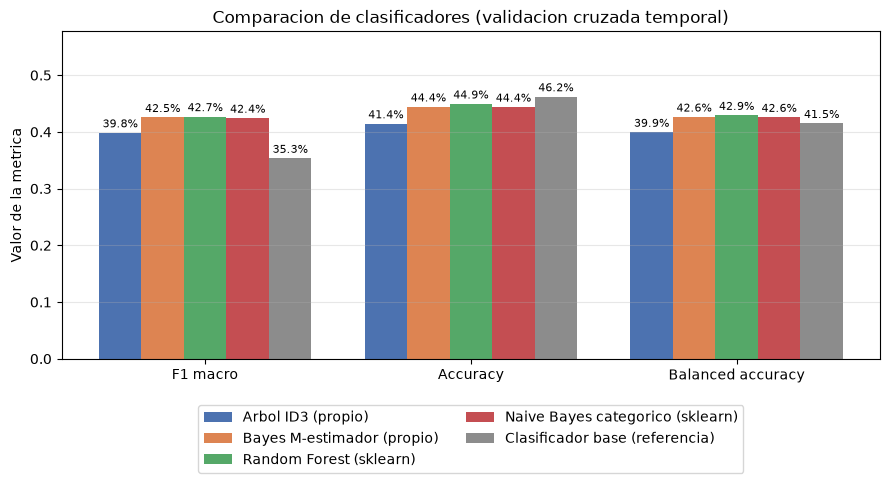

In [14]:
fig = R.grafico_comparacion_modelos(resultados)
plt.show()

### 6.2 F1 macro por año de validación

Se representa la variación anual del F1 macro de cada configuración seleccionada. Esta información complementa los promedios y permite identificar diferencias de estabilidad entre años.


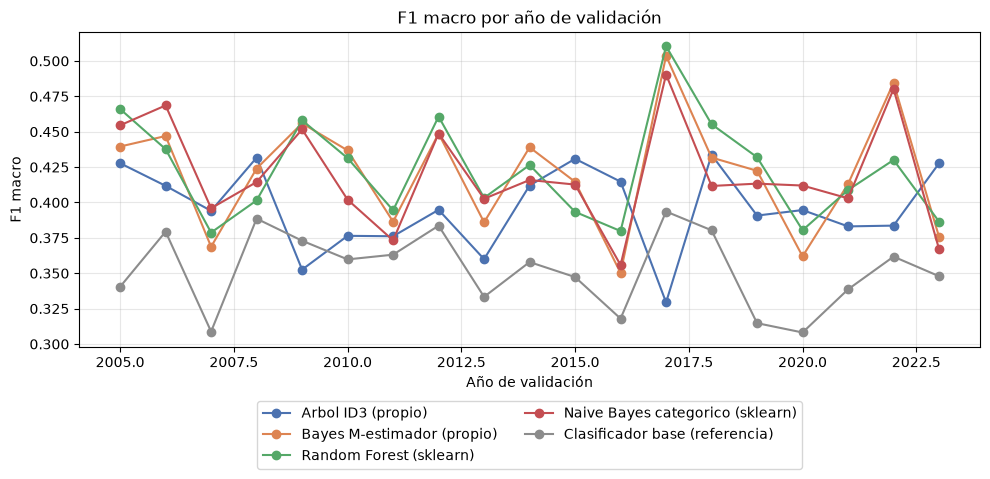

In [15]:
def serie_por_anio(busqueda):
    idx = busqueda.selected_index_
    return {
        anio: busqueda.cv_results_[f"split{i}_test_f1_macro"][idx]
        for i, anio in enumerate(validation_years)
    }

series_por_anio = {
    "Arbol ID3 (propio)": serie_por_anio(busqueda_arbol),
    "Bayes M-estimador (propio)": serie_por_anio(busqueda_bayes),
    "Random Forest (sklearn)": serie_por_anio(busqueda_rf),
    "Naive Bayes categorico (sklearn)": serie_por_anio(busqueda_nb),
    "Clasificador base (referencia)": serie_base_por_anio,
}
fig = R.grafico_f1_por_anio(series_por_anio)
plt.show()

### 6.3 Matrices de confusión (validación agrupada)

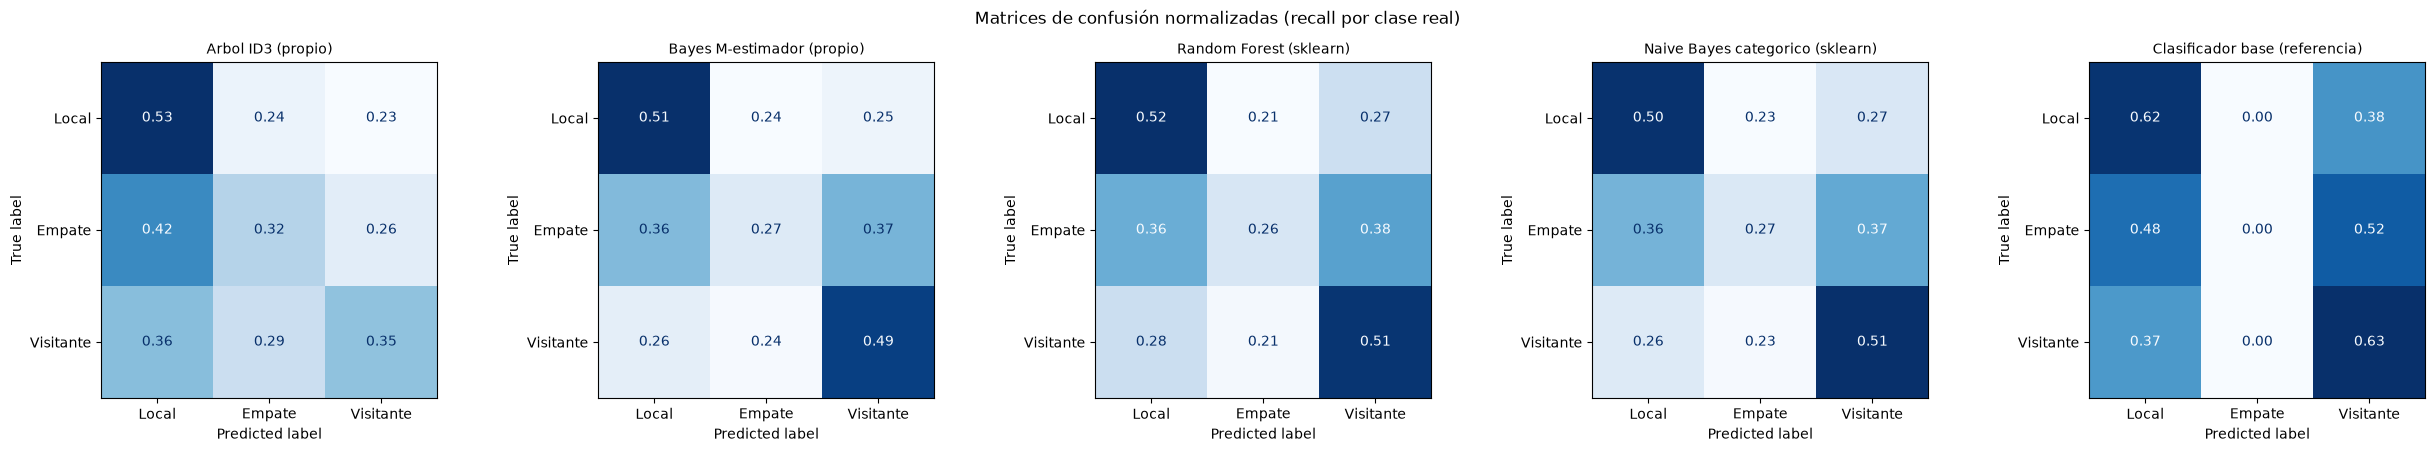

In [16]:
fig = R.grafico_matrices_confusion(y_real, predicciones)
plt.show()

### 6.4 Sensibilidad a las ventanas temporales

El análisis se calcula al ejecutar esta sección, mediante `evaluar_ventanas` de `../src/evaluacion.py`. Se mantienen fijos los hiperparámetros seleccionados para Bayes e ID3 y se modifica una ventana por vez. Los atributos se reconstruyen cuando cambia su historial y los cálculos compartidos se reutilizan en memoria.

Las barras muestran un error estándar descriptivo entre años, no una prueba de equivalencia estadística. Este análisis no vuelve a seleccionar los modelos ni consulta el test. La reconstrucción de atributos y la evaluación de variantes pueden tardar varios minutos.


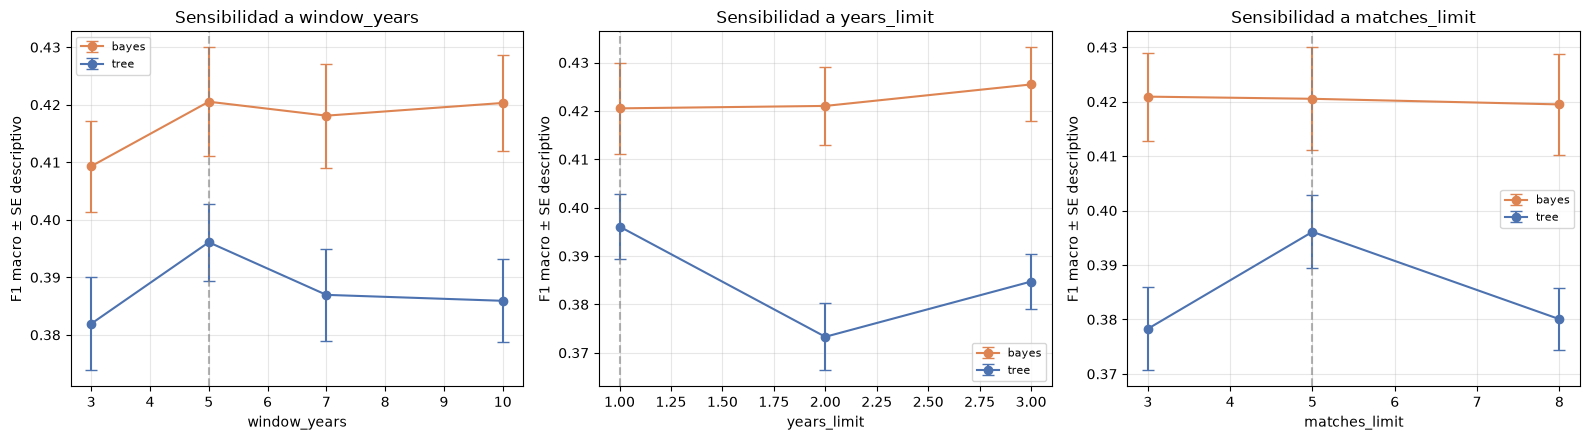

In [17]:
resultados_ventanas = evaluar_ventanas(
    dataset,
    {"bayes": busqueda_bayes.selected_template_, "tree": busqueda_arbol.selected_template_},
    validation_years=validation_years,
    window_years=window_years,
)
fig = R.grafico_ventanas(resultados_ventanas, window_years=window_years)
plt.show()


### 6.5 Sensibilidad de F1 macro a los hiperparámetros

Los candidatos de la búsqueda se agrupan según el valor de cada hiperparámetro. Su media y los percentiles 25–75 se representan mediante `../src/reportes.py`. Las curvas son descriptivas: los demás parámetros también varían y pueden interactuar, por lo que no permiten atribuir causalmente la variación a un único parámetro.


In [18]:

# Los propios objetos de busqueda ya tienen los ~500 candidatos evaluados
# en memoria (cv_results_); no hace falta releer nada de disco.
cv_results_arbol = pd.DataFrame(busqueda_arbol.cv_results_)
cv_results_bayes = pd.DataFrame(busqueda_bayes.cv_results_)


#### Hiperparámetros clave, en detalle

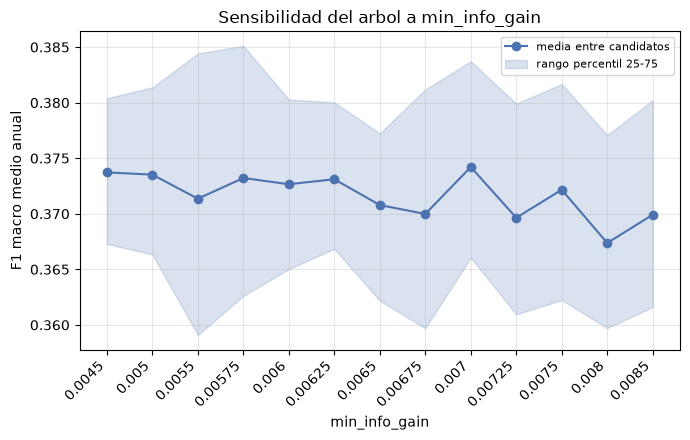

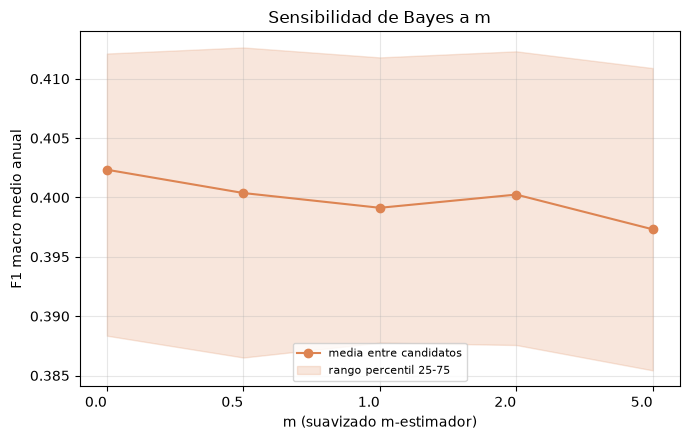

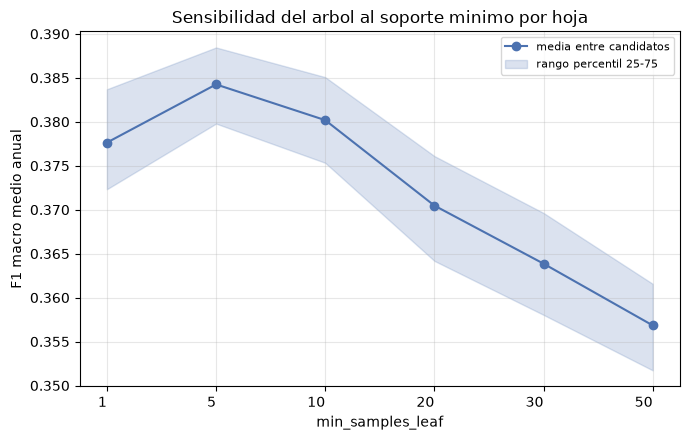

In [19]:

fig = R.grafico_sensibilidad_hiperparametro(
    cv_results_arbol, "param_model__min_info_gain", "min_info_gain",
    "Sensibilidad del arbol a min_info_gain", color=R.MODEL_COLORS["Arbol ID3 (propio)"],
)
plt.show()


fig = R.grafico_sensibilidad_hiperparametro(
    cv_results_bayes, "param_model__m", "m (suavizado m-estimador)",
    "Sensibilidad de Bayes a m", color=R.MODEL_COLORS["Bayes M-estimador (propio)"],
)
plt.show()

fig = R.grafico_sensibilidad_hiperparametro(
    cv_results_arbol, "param_model__min_samples_leaf", "min_samples_leaf",
    "Sensibilidad del arbol al soporte minimo por hoja", color=R.MODEL_COLORS["Arbol ID3 (propio)"],
)
plt.show()


#### Comparación conjunta de los hiperparámetros

Se presenta el rango entre el mayor y el menor F1 macro promedio de los grupos asociados a cada hiperparámetro. La comparación resume la sensibilidad observada dentro de la búsqueda realizada y no constituye una medida causal de importancia.


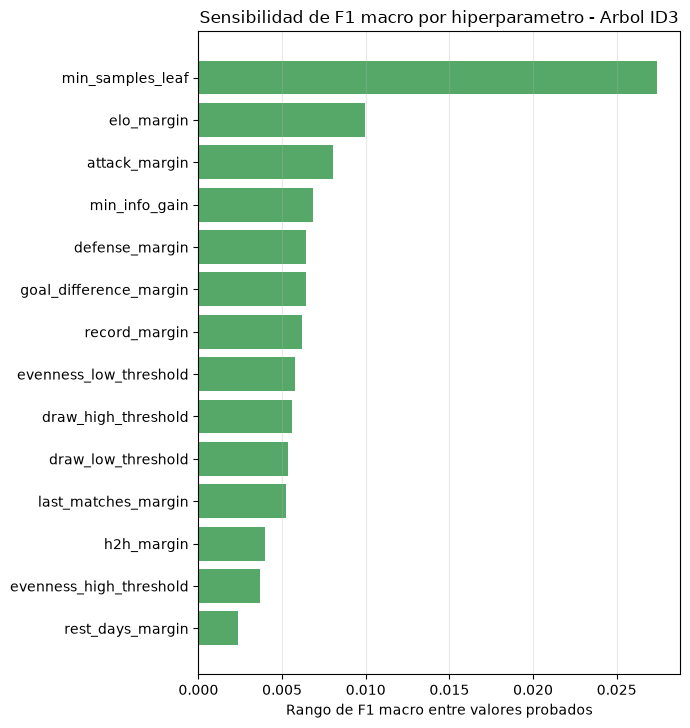

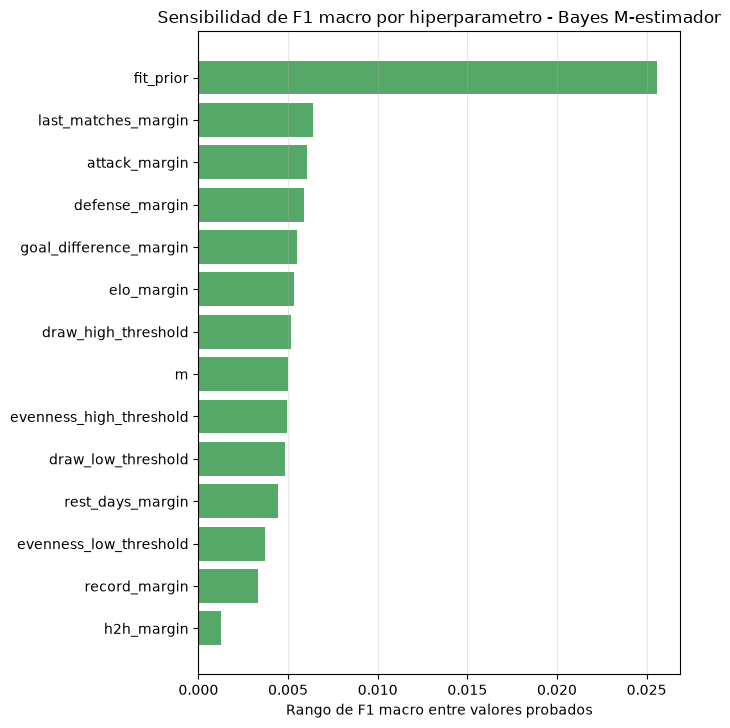

In [ ]:

etiquetas_arbol = {
    "param_model__min_samples_leaf": "min_samples_leaf",
    "param_model__min_info_gain": "min_info_gain",

    "param_preprocessing__differences__discretizer__h2h_margin": "h2h_margin",
    "param_preprocessing__differences__discretizer__rest_days_margin": "rest_days_margin",
    "param_preprocessing__differences__discretizer__record_margin": "record_margin",
    "param_preprocessing__differences__discretizer__last_matches_margin": "last_matches_margin",
    "param_preprocessing__differences__discretizer__goal_difference_margin": "goal_difference_margin",
    "param_preprocessing__differences__discretizer__elo_margin": "elo_margin",
    "param_preprocessing__differences__discretizer__defense_margin": "defense_margin",
    "param_preprocessing__differences__discretizer__attack_margin": "attack_margin",
    "param_preprocessing__draw_rate__discretizer__low_threshold": "draw_low_threshold",
    "param_preprocessing__draw_rate__discretizer__high_threshold": "draw_high_threshold",
    "param_preprocessing__evenness__discretizer__low_threshold": "evenness_low_threshold",
    "param_preprocessing__evenness__discretizer__high_threshold": "evenness_high_threshold",
}
fig = R.grafico_importancia_hiperparametros(
    cv_results_arbol, etiquetas_arbol, "Sensibilidad de F1 macro por hiperparametro - Arbol ID3",
)
plt.show()

etiquetas_bayes = {
    "param_model__m": "m", [0.5467, 0.6355
    "param_model__fit_prior": "fit_prior",
    "param_preprocessing__differences__discretizer__h2h_margin": "h2h_margin",
    "param_preprocessing__differences__discretizer__rest_days_margin": "rest_days_margin",
    "param_preprocessing__differences__discretizer__record_margin": "record_margin",
    "param_preprocessing__differences__discretizer__last_matches_margin": "last_matches_margin",
    "param_preprocessing__differences__discretizer__goal_difference_margin": "goal_difference_margin",
    "param_preprocessing__differences__discretizer__elo_margin": "elo_margin",
    "param_preprocessing__differences__discretizer__defense_margin": "defense_margin",
    "param_preprocessing__differences__discretizer__attack_margin": "attack_margin",
    "param_preprocessing__draw_rate__discretizer__low_threshold": "draw_low_threshold",
    "param_preprocessing__draw_rate__discretizer__high_threshold": "draw_high_threshold",
    "param_preprocessing__evenness__discretizer__low_threshold": "evenness_low_threshold",
    "param_preprocessing__evenness__discretizer__high_threshold": "evenness_high_threshold",
}
fig = R.grafico_importancia_hiperparametros(
    cv_results_bayes, etiquetas_bayes, "Sensibilidad de F1 macro por hiperparametro - Bayes M-estimador",
)
plt.show()


## 7. Interpretación de la validación

Los modelos se comparan según el F1 macro medio anual empleado en la selección de hiperparámetros. Esta medida se distingue del F1 calculado sobre las predicciones agrupadas y se complementa con accuracy, balanced accuracy y métricas de detección de empates.

Las diferencias pequeñas no se interpretan como evidencia de superioridad estadística sin un análisis específico. Las gráficas de sensibilidad describen las configuraciones evaluadas, pero no demuestran un óptimo global ni un límite de rendimiento del problema. La referencia histórica permite analizar cuánto cambia el equilibrio entre clases al utilizar un modelo entrenado.

Los resultados presentados corresponden a las celdas ejecutadas en este notebook, con el mismo dataset y protocolo de validación.


## 8. Evaluación final con un único modelo por clasificador

Una vez seleccionados los hiperparámetros mediante validación, cada clasificador se entrena con los partidos de 2019–2023. Se conserva ese mismo modelo para todos los partidos de test, incluidos los de 2025. La regla base utiliza el historial anterior a cada partido.

El ajuste final conserva la ventana de cinco años utilizada en los folds. No se entrena con todo el historial desde 1932 ni se realizan nuevos ajustes dentro del test. Los atributos incorporan resultados anteriores a cada encuentro, de acuerdo con un escenario de predicción partido a partido.

Las métricas de test se interpretan sin modificar posteriormente los hiperparámetros a partir de ellas. El período disponible termina el 30 de junio de 2025.


In [ ]:
X_test = test[pipeline_input_attributes].copy()
y_test = test["result"].copy()

modelos_finales = {}

def entrenar_final_y_predecir(busqueda, nombre):
    modelos_finales[nombre] = ajustar_final(
        busqueda.selected_template_, train, pipeline_input_attributes,
        window_years=window_years, [0.5467, 0.6355 test_start=test_start,
    )
    return modelos_finales[nombre].predict(X_test)

predicciones_test = {
    "Arbol ID3 (propio)": entrenar_final_y_predecir(busqueda_arbol, "arbol"),
    "Bayes M-estimador (propio)": entrenar_final_y_predecir(busqueda_bayes, "bayes"),
    "Random Forest (sklearn)": entrenar_final_y_predecir(busqueda_rf, "rf"),
    "Naive Bayes categorico (sklearn)": entrenar_final_y_predecir(busqueda_nb, "nb"),
}

# Se informa la distribución de predicciones por clase. Los escalares
# se convierten a tipos nativos para facilitar la lectura de la salida.
for nombre, y_pred in predicciones_test.items():
    valores, cuentas = np.unique(y_pred, return_counts=True)
    conteo = {str(valor): int(cuenta) for valor, cuenta in zip(valores, cuentas)}
    print(nombre, "-> predicciones por clase:", conteo)

# El clasificador base no se entrena: para cada partido de test busca el
# historial de ambos equipos en `dataset` completo (incluye partidos de
# test anteriores a esa fecha puntual, igual que en un uso real), filtrado
# causalmente por fecha dentro de base_classifier/get_record.
predicciones_test["Clasificador base (referencia)"] = np.array([
    base_classifier(dataset, BASE_YEARS_LIMIT, fila) for _, fila in test.iterrows()
])

resultados_test = {}
for nombre, y_pred in predicciones_test.items():
    reporte_dict = classification_report(
        y_test, y_pred, labels=labels, target_names=target_names, output_dict=True, zero_division=0,
    )
    resultados_test[nombre] = { [0.5467, 0.6355
        "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "f1_empate": reporte_dict["Empate"]["f1-score"],
        "recall_empate": reporte_dict["Empate"]["recall"],
    }
    print(f"\n{nombre}")
    print(classification_report(y_test, y_pred, labels=labels, target_names=target_names, zero_division=0))

Arbol ID3 (propio) -> predicciones por clase: {'E': 140, 'L': 198, 'V': 134}
Bayes M-estimador (propio) -> predicciones por clase: {'E': 55, 'L': 225, 'V': 192}
Random Forest (sklearn) -> predicciones por clase: {'E': 45, 'L': 240, 'V': 187}
Naive Bayes categorico (sklearn) -> predicciones por clase: {'E': 55, 'L': 216, 'V': 201}

Arbol ID3 (propio)
              precision    recall  f1-score   support

       Local       0.49      0.51      0.50       190
      Empate       0.31      0.34      0.32       131
   Visitante       0.39      0.34      0.36       151

    accuracy                           0.41       472
   macro avg       0.40      0.40      0.40       472
weighted avg       0.41      0.41      0.41       472


Bayes M-estimador (propio)
              precision    recall  f1-score   support

       Local       0.54      0.64      0.59       190
      Empate       0.42      0.18      0.25       131
   Visitante       0.46      0.58      0.51       151

    accuracy         

### 8.1 Tabla resumen y gráfica — conjunto de test

In [22]:
R.tabla_resumen_modelos(resultados_test)

,F1 macro,Accuracy,Balanced accuracy,F1 Empate,Recall Empate
Arbol ID3 (propio),39.65%,40.89%,39.69%,32.47%,33.59%
Bayes M-estimador (propio),44.95%,49.36%,46.68%,24.73%,17.56%
Random Forest (sklearn),42.87%,48.73%,45.51%,18.18%,12.21%
Naive Bayes categorico (sklearn),42.17%,47.03%,44.36%,19.35%,13.74%
Clasificador base (referencia),35.84%,46.40%,42.82%,0.00%,0.00%


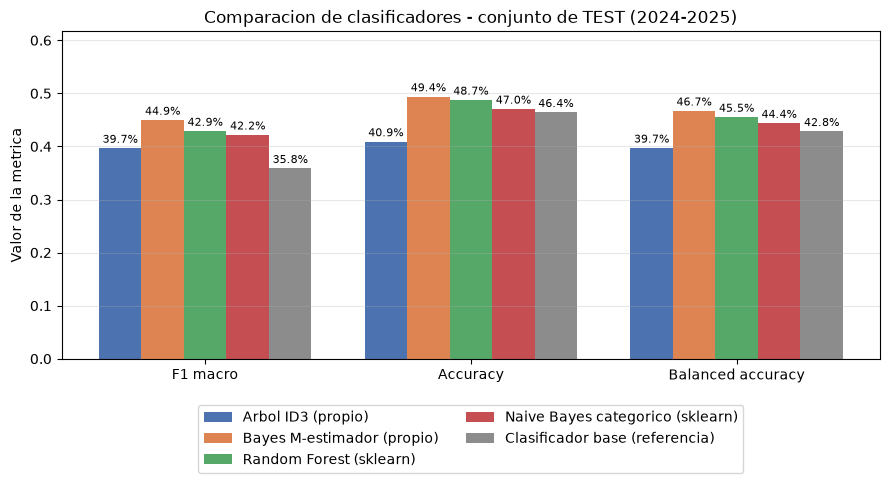

In [23]:
fig = R.grafico_comparacion_modelos(
    resultados_test,
    titulo="Comparacion de clasificadores - conjunto de TEST (2024-2025)",
)
plt.show()

### 8.2 Matrices de confusión — conjunto de test

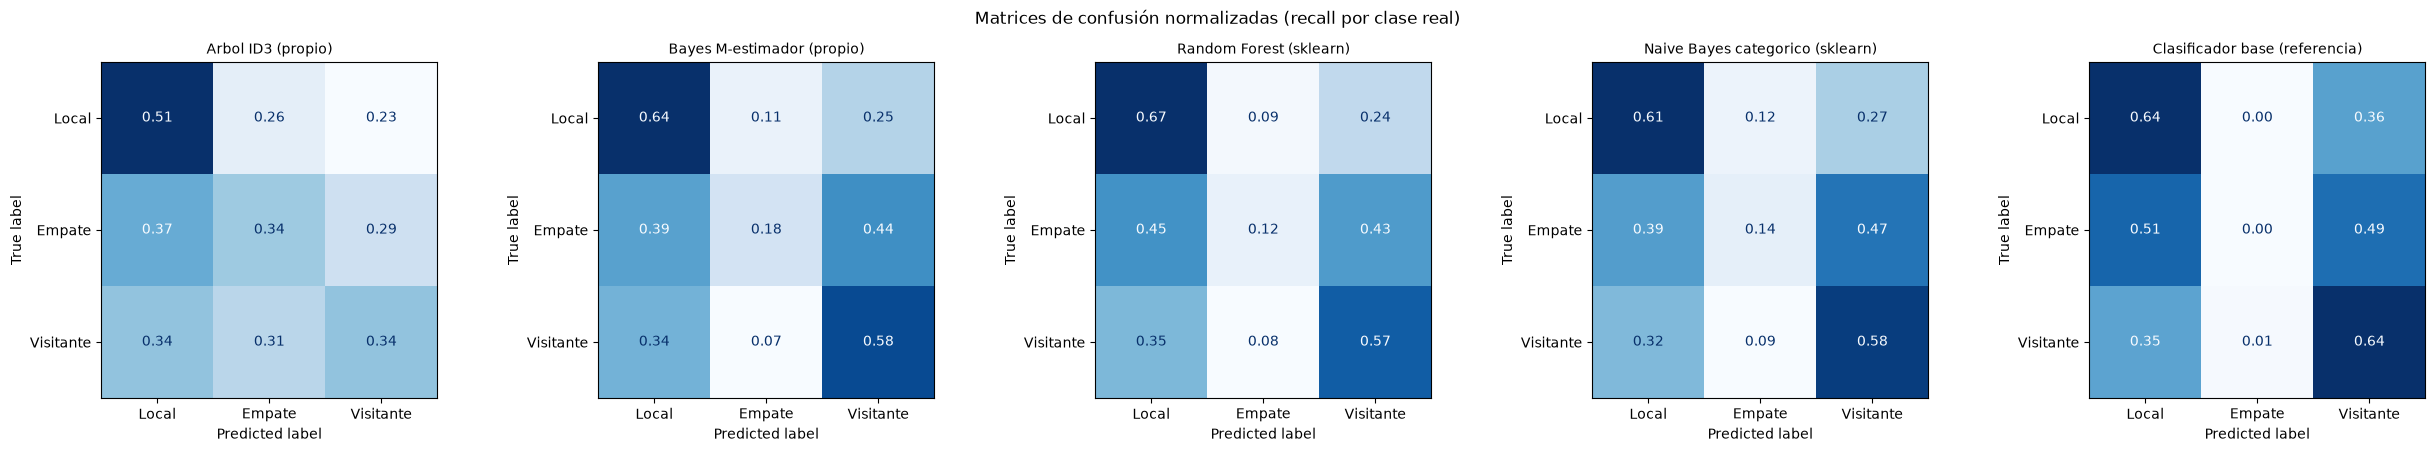

In [24]:
fig = R.grafico_matrices_confusion(y_test.to_numpy(), predicciones_test)
plt.show()

Estas métricas describen el comportamiento del modelo fijo durante el período de test disponible. Este escenario se distingue del reentrenamiento anual utilizado en validación. Los hiperparámetros no se modifican a partir de los resultados de test.


In [25]:
print("Intervalo de confianza al 95% para la tasa de error en test\n")
n = len(y_test)
print(f"n = {n} partidos de test\n")
for nombre, metricas in resultados_test.items():
    error_s = 1 - metricas["accuracy"]
    margen = 1.96 * np.sqrt(error_s * (1 - error_s) / n)
    ic_inferior = error_s - margen
    ic_superior = error_s + margen
    print(f"{nombre}")
    print(f"  error_s(h)  = {error_s:.4f}  (accuracy = {metricas['accuracy']:.4f})")
    print(f"  IC 95%      = [{ic_inferior:.4f}, {ic_superior:.4f}]")
    print()

Intervalo de confianza al 95% para la tasa de error en test

n = 472 partidos de test

Arbol ID3 (propio)
  error_s(h)  = 0.5911  (accuracy = 0.4089)
  IC 95%      = [0.5467, 0.6355]

Bayes M-estimador (propio)
  error_s(h)  = 0.5064  (accuracy = 0.4936)
  IC 95%      = [0.4613, 0.5515]

Random Forest (sklearn)
  error_s(h)  = 0.5127  (accuracy = 0.4873)
  IC 95%      = [0.4676, 0.5578]

Naive Bayes categorico (sklearn)
  error_s(h)  = 0.5297  (accuracy = 0.4703)
  IC 95%      = [0.4846, 0.5747]

Clasificador base (referencia)
  error_s(h)  = 0.5360  (accuracy = 0.4640)
  IC 95%      = [0.4910, 0.5810]

